<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizerClusteringModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [3]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head(10)

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)
5,Kalkaska,Michigan,2008,8,1,Murder or Manslaughter,Male,3,White,Male,25.0,White,Acquaintance,Blunt Object,0,2,Child (0-12),Young Adult (20-29)
6,Spokane,Washington,2001,3,1,Murder or Manslaughter,Male,37,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
7,Baltimore city,Maryland,2005,1,13,Murder or Manslaughter,Male,22,Black,Male,0.0,White,Acquaintance,Handgun,0,0,Young Adult (20-29),NaN
8,Lafayette,Louisiana,2014,2,1,Murder or Manslaughter,Male,49,White,Male,15.0,Black,Husband,Firearm,0,0,Adult (30-49),Teen (13-19)
9,Gaston,North Carolina,2009,4,1,Murder or Manslaughter,Female,17,Black,Male,21.0,Black,Stranger,Handgun,0,1,Teen (13-19),Young Adult (20-29)


EDA (Exploratory Data Analysis)

<ipython-input-4-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


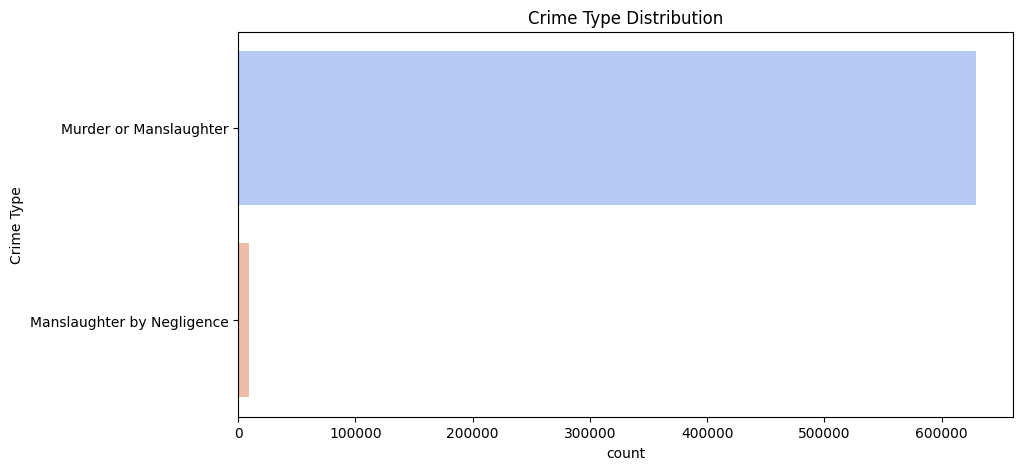

In [4]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-5-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


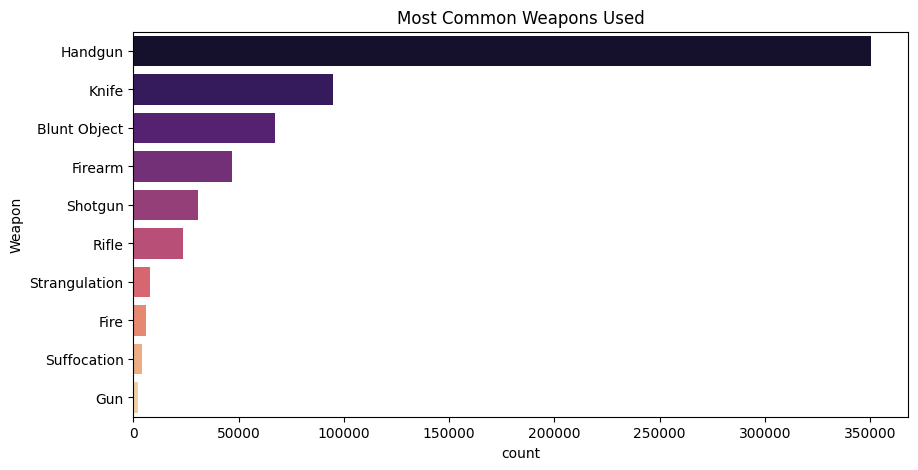

In [5]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

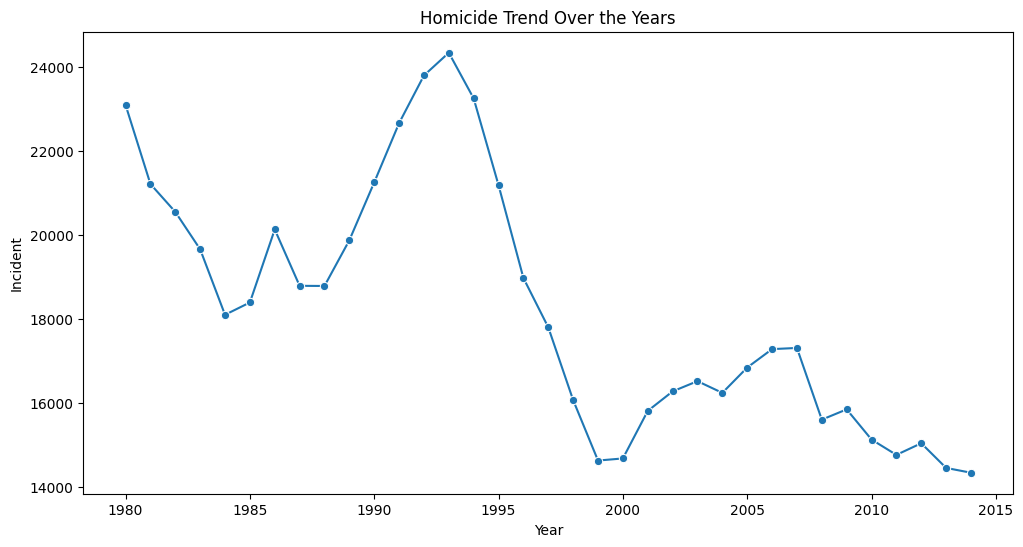

In [6]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [7]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident","Crime Type","Victim Race","Perpetrator Race"])

In [8]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Male,Male,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Male,Male,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Male,Male,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Female,Male,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


In [9]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Victim Sex,0
Perpetrator Sex,0
Relationship,0
Weapon,0
Victim Count,0
Perpetrator Count,0


In [10]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age Group"])

In [11]:
# Getting a sample percentage of data to preprocess
data_percentage = 0.5
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [12]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [13]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group
484984,Baltimore city,Maryland,1996,8,Male,Male,Acquaintance,Handgun,0,0,Senior (50+)
608445,Essex,New Jersey,2013,9,Male,Male,Stranger,Handgun,0,0,Young Adult (20-29)
417612,Wayne,Michigan,1997,11,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29)
372692,Dade,Florida,1995,12,Male,Male,Son,Blunt Object,0,0,Child (0-12)
402028,Los Angeles,California,2002,11,Male,Male,Stranger,Handgun,0,0,Teen (13-19)


In [14]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319227 entries, 484984 to 190407
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   City               319227 non-null  object
 1   State              319227 non-null  object
 2   Year               319227 non-null  int64 
 3   Month              319227 non-null  int64 
 4   Victim Sex         319227 non-null  object
 5   Perpetrator Sex    319227 non-null  object
 6   Relationship       319227 non-null  object
 7   Weapon             319227 non-null  object
 8   Victim Count       319227 non-null  int64 
 9   Perpetrator Count  319227 non-null  int64 
 10  Victim Age Group   319227 non-null  object
dtypes: int64(4), object(7)
memory usage: 29.2+ MB


In [15]:
# Get value count for city
homicide_data["City"].value_counts()

,count
City,
Los Angeles,22137
New York,19174
Cook,11086
Wayne,9902
Harris,8179
...,...
Mahaska,1
Ellsworth,1
Concho,1


In [16]:
# Get value count for state
homicide_data["State"].value_counts()

,count
State,
California,49939
Texas,31010
New York,24526
Florida,18463
Michigan,14178
Illinois,12818
Pennsylvania,12285
Georgia,10642
North Carolina,10240


In [17]:
# Drop state and city due to high categorical count
homicide_data = homicide_data.drop(columns=["City","State"])

In [18]:
# Viewing the data
homicide_data.head()

,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group
484984,1996,8,Male,Male,Acquaintance,Handgun,0,0,Senior (50+)
608445,2013,9,Male,Male,Stranger,Handgun,0,0,Young Adult (20-29)
417612,1997,11,Male,Male,Acquaintance,Firearm,0,0,Young Adult (20-29)
372692,1995,12,Male,Male,Son,Blunt Object,0,0,Child (0-12)
402028,2002,11,Male,Male,Stranger,Handgun,0,0,Teen (13-19)


In [19]:
# Get weapon value count
homicide_data["Weapon"].value_counts()

,count
Weapon,
Handgun,175252
Knife,47515
Blunt Object,33759
Firearm,23587
Shotgun,15290
Rifle,11676
Strangulation,4004
Fire,3096
Suffocation,1981


Feature Engineering

In [20]:
# Time Series Analysis
homicide_data["Date"] = pd.to_datetime(homicide_data[['Year', 'Month']].assign(DAY=1))

# Set Date as the index
homicide_data.set_index('Date', inplace=True)

# Ensure the data is sorted
homicide_data = homicide_data.sort_index()

# Count crimes per month
crime_trends = homicide_data.resample('M').size()

# Display the first few rows
crime_trends.head()

<ipython-input-20-6dfaa33dc0fc>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crime_trends = homicide_data.resample('M').size()


,0
Date,
1980-01-31,923
1980-02-29,816
1980-03-31,832
1980-04-30,926
1980-05-31,921


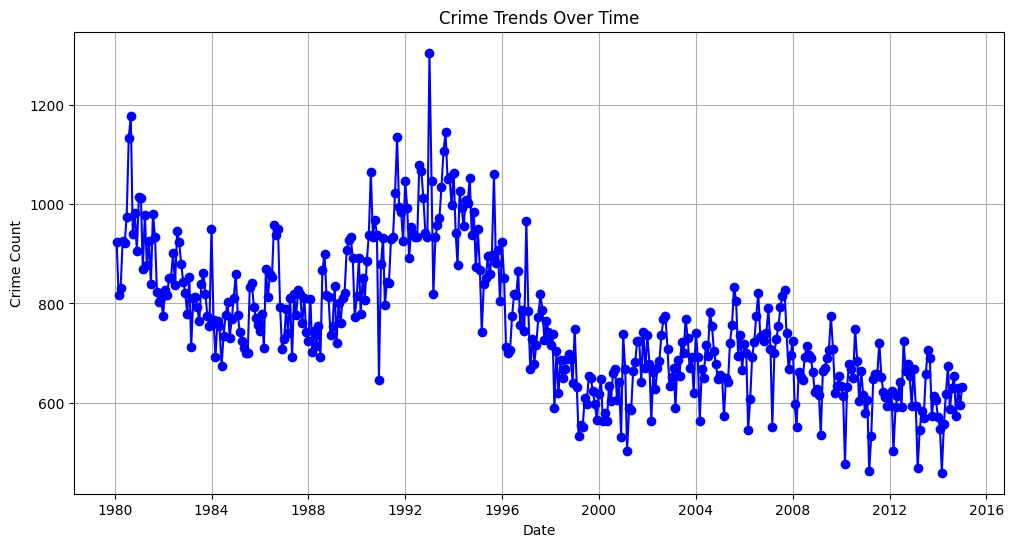

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(crime_trends, marker='o', linestyle='-', color='b')
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.title("Crime Trends Over Time")
plt.grid()
plt.show()


In [22]:
# One hot encoding categorical features
homicide_data = pd.get_dummies(homicide_data, columns=["Victim Sex", "Perpetrator Sex", "Relationship", "Weapon", "Victim Age Group"], drop_first=False)

In [23]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29)
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,1980,1,0,0,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
1980-01-01,1980,1,0,0,False,True,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False


In [24]:
# Analyze new columns
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 319227 entries, 1980-01-01 to 2014-12-01
Data columns (total 56 columns):
 #   Column                                Non-Null Count   Dtype
---  ------                                --------------   -----
 0   Year                                  319227 non-null  int64
 1   Month                                 319227 non-null  int64
 2   Victim Count                          319227 non-null  int64
 3   Perpetrator Count                     319227 non-null  int64
 4   Victim Sex_Female                     319227 non-null  bool 
 5   Victim Sex_Male                       319227 non-null  bool 
 6   Perpetrator Sex_Female                319227 non-null  bool 
 7   Perpetrator Sex_Male                  319227 non-null  bool 
 8   Relationship_Acquaintance             319227 non-null  bool 
 9   Relationship_Boyfriend                319227 non-null  bool 
 10  Relationship_Boyfriend/Girlfriend     319227 non-null  bool 
 11  Relationsh

In [25]:
# Select features after one-hot encoding
features = [
    "Month", "Victim Count", "Perpetrator Count",
    "Victim Sex_Female", "Victim Sex_Male",
    "Perpetrator Sex_Female", "Perpetrator Sex_Male",
    "Relationship_Acquaintance", "Relationship_Boyfriend",
    "Relationship_Boyfriend/Girlfriend", "Relationship_Brother",
    "Relationship_Common-Law Husband", "Relationship_Common-Law Wife",
    "Relationship_Daughter", "Relationship_Employee", "Relationship_Employer",
    "Relationship_Ex-Husband", "Relationship_Ex-Wife", "Relationship_Family",
    "Relationship_Father", "Relationship_Friend", "Relationship_Girlfriend",
    "Relationship_Husband", "Relationship_In-Law", "Relationship_Mother",
    "Relationship_Neighbor", "Relationship_Sister", "Relationship_Son",
    "Relationship_Stepdaughter", "Relationship_Stepfather", "Relationship_Stepmother",
    "Relationship_Stepson", "Relationship_Stranger", "Relationship_Wife",
    "Weapon_Blunt Object", "Weapon_Drowning", "Weapon_Drugs",
    "Weapon_Explosives", "Weapon_Fall", "Weapon_Fire", "Weapon_Firearm",
    "Weapon_Gun", "Weapon_Handgun", "Weapon_Knife", "Weapon_Poison",
    "Weapon_Rifle", "Weapon_Shotgun", "Weapon_Strangulation", "Weapon_Suffocation",
    "Victim Age Group_Adult (30-49)", "Victim Age Group_Child (0-12)",
    "Victim Age Group_Senior (50+)", "Victim Age Group_Teen (13-19)",
    "Victim Age Group_Unknown", "Victim Age Group_Young Adult (20-29)"
]

# Assign the feature matrix
X = homicide_data[features]


In [26]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Rifle,Weapon_Shotgun,Weapon_Strangulation,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29)
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,1980,1,0,0,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
1980-01-01,1980,1,0,0,False,True,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False


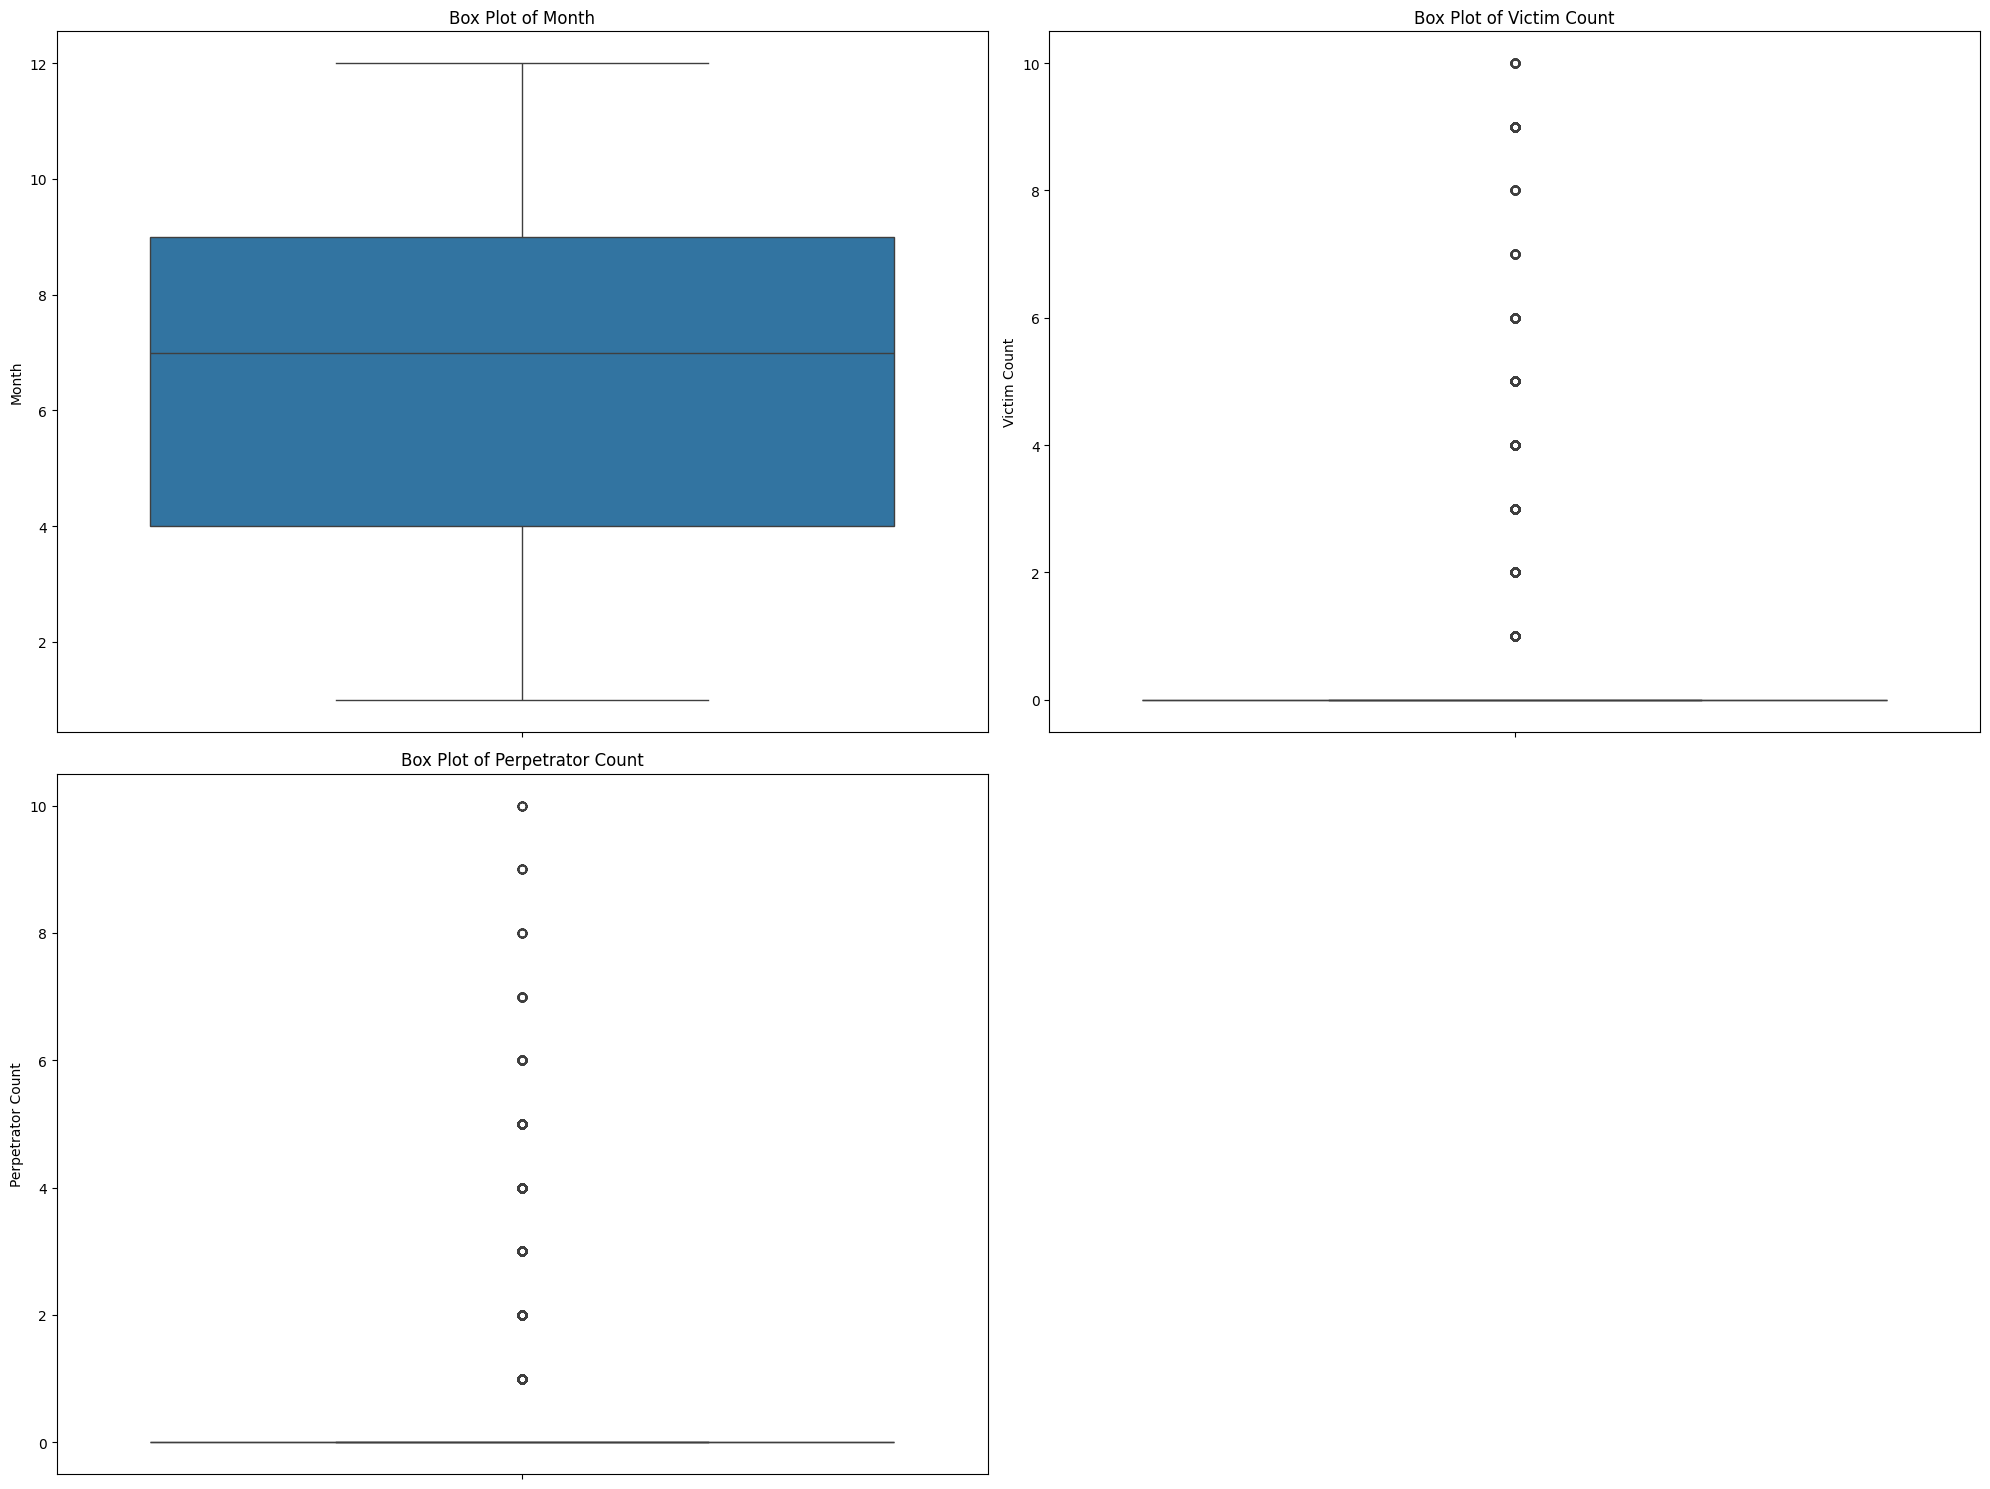

In [27]:
# Figure size
plt.figure(figsize=(20, 15))

# Define numerical and categorical features separately
numerical_features = ["Month", "Victim Count", "Perpetrator Count"]
categorical_features = [feature for feature in features if feature not in numerical_features]

# Number of numerical features
num_numerical = len(numerical_features)

# Plot box plots for numerical features
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=homicide_data[feature])
    plt.title(f"Box Plot of {feature}")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


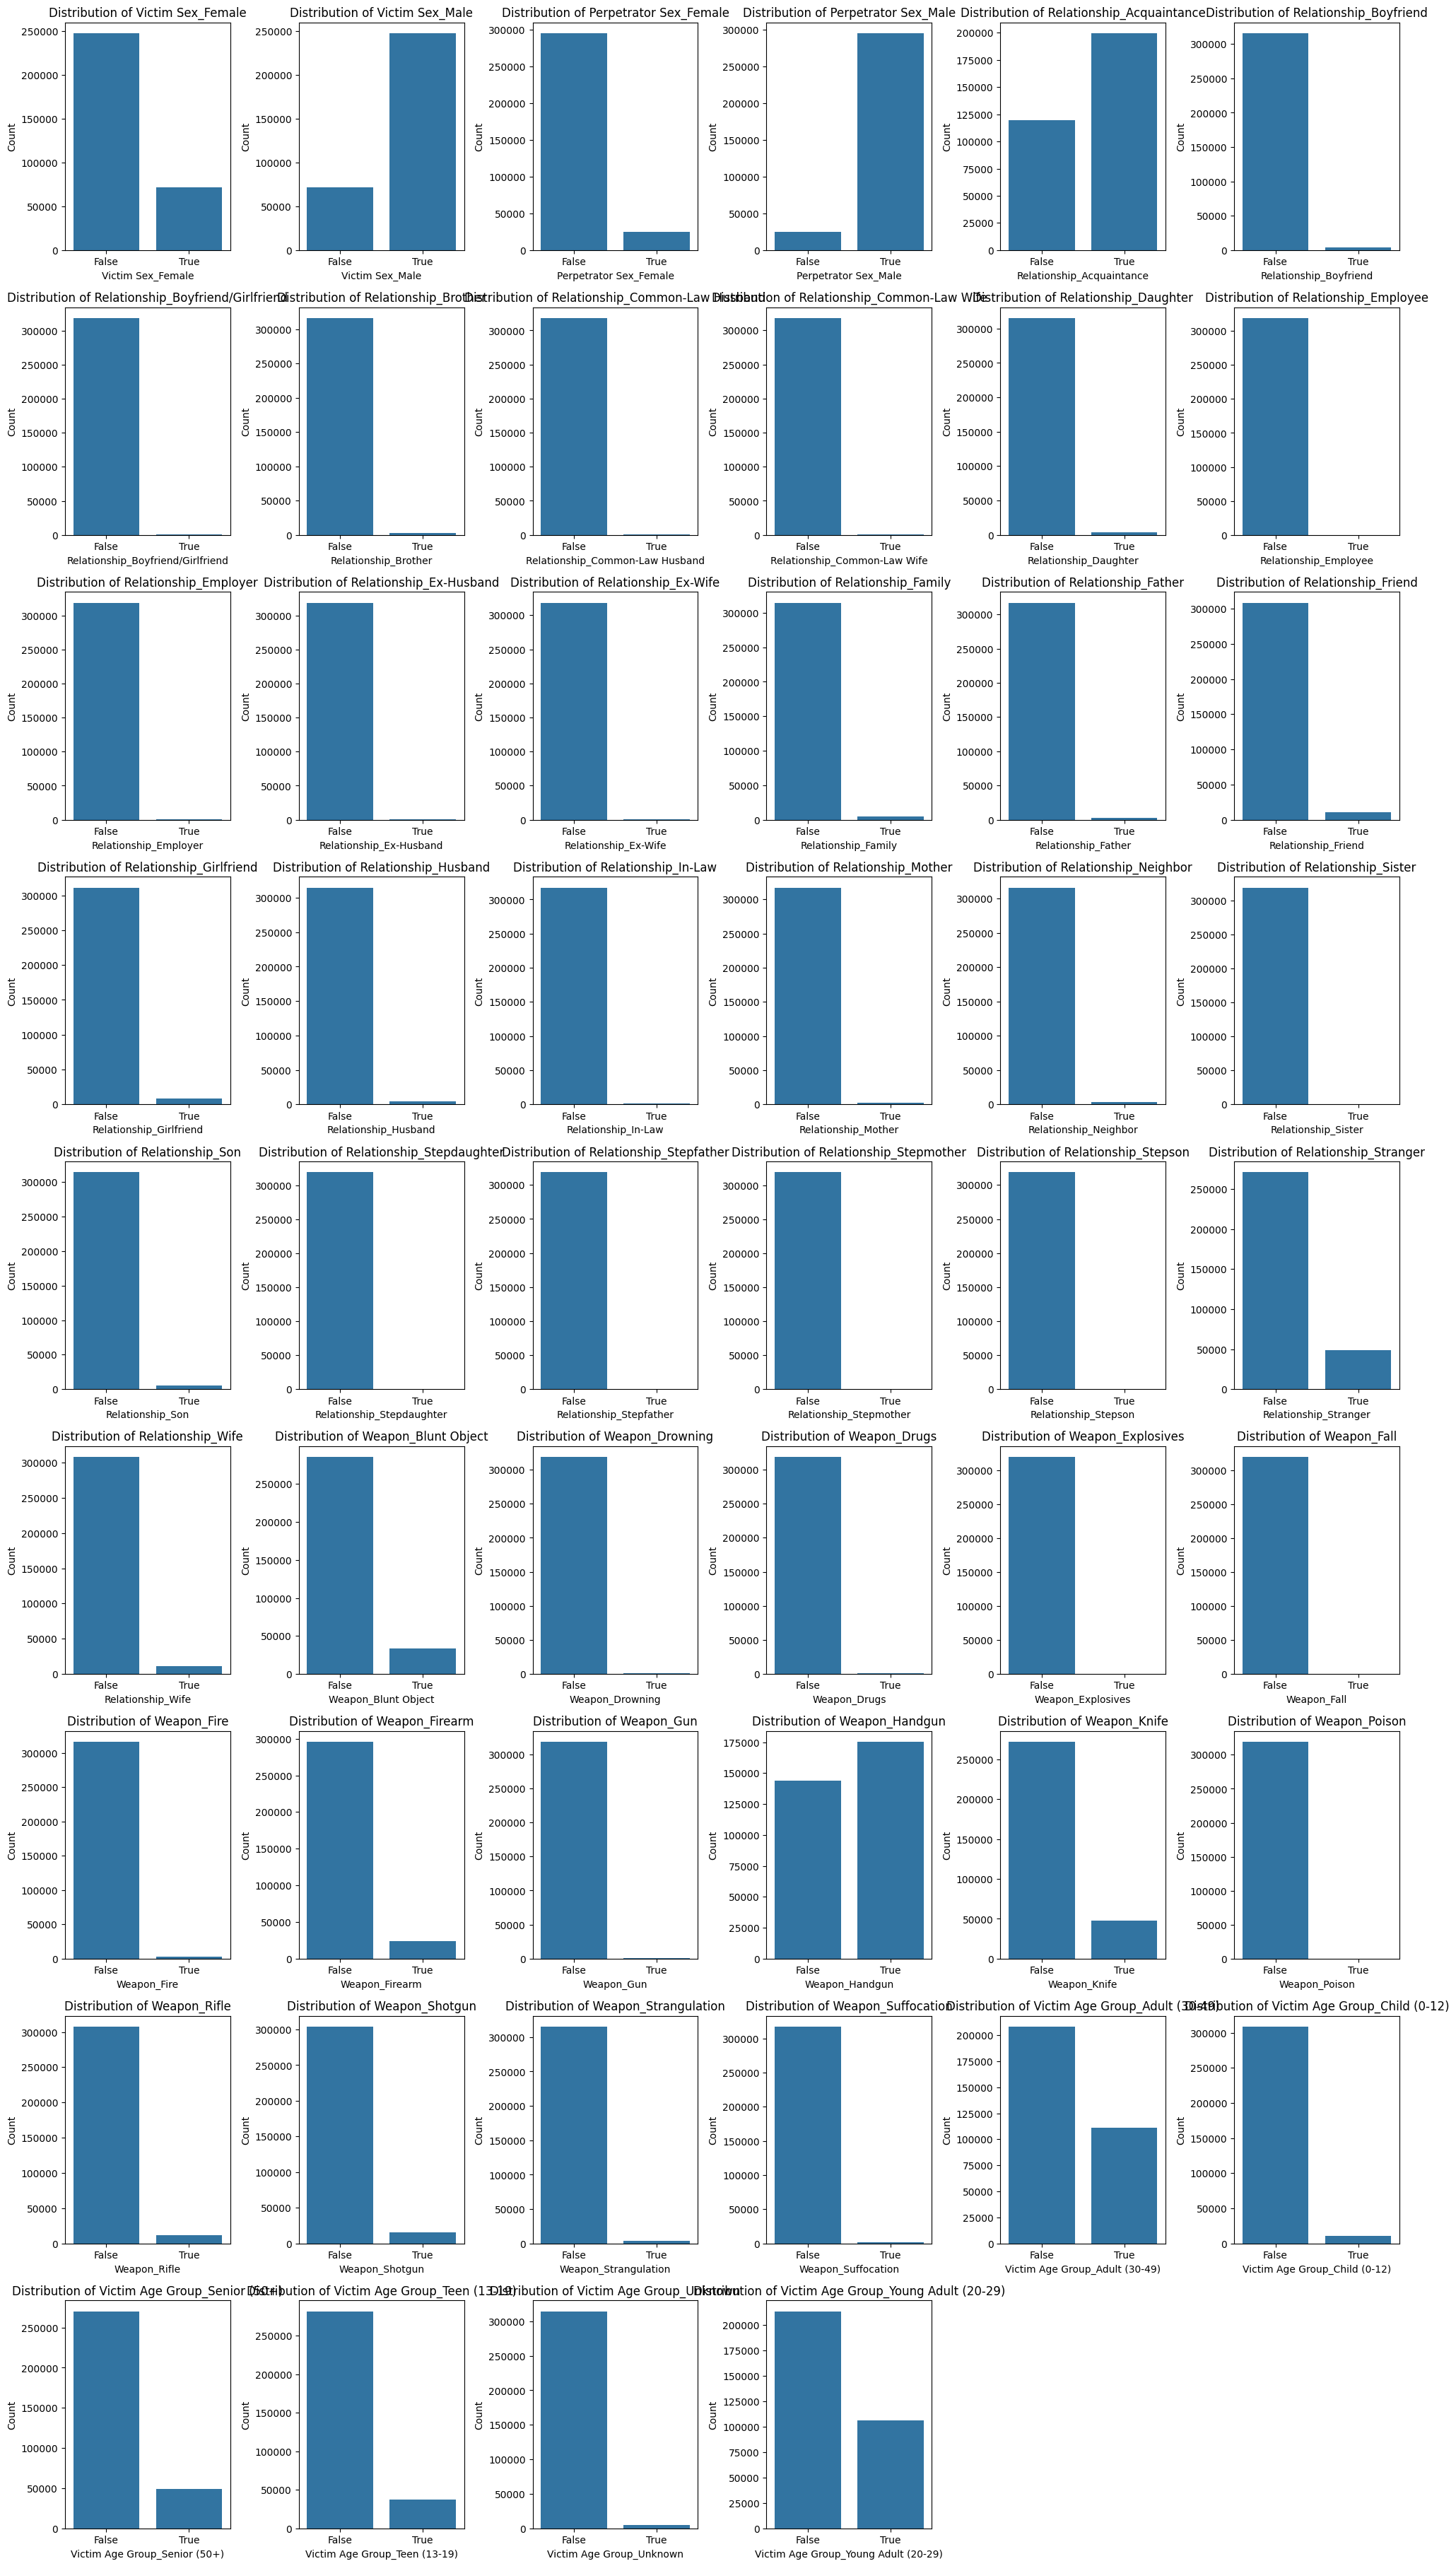

In [28]:
# Plot bar plots for categorical features
plt.figure(figsize=(20, 40))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(10, 6, i)
    sns.barplot(x=homicide_data[feature].value_counts().index, y=homicide_data[feature].value_counts().values)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [29]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
homicide_data["Month"].value_counts()

,count
Month,
7,29360
8,29266
12,27419
9,27028
10,26952
6,26765
5,26663
1,26662
3,25653


KMeans Clustering

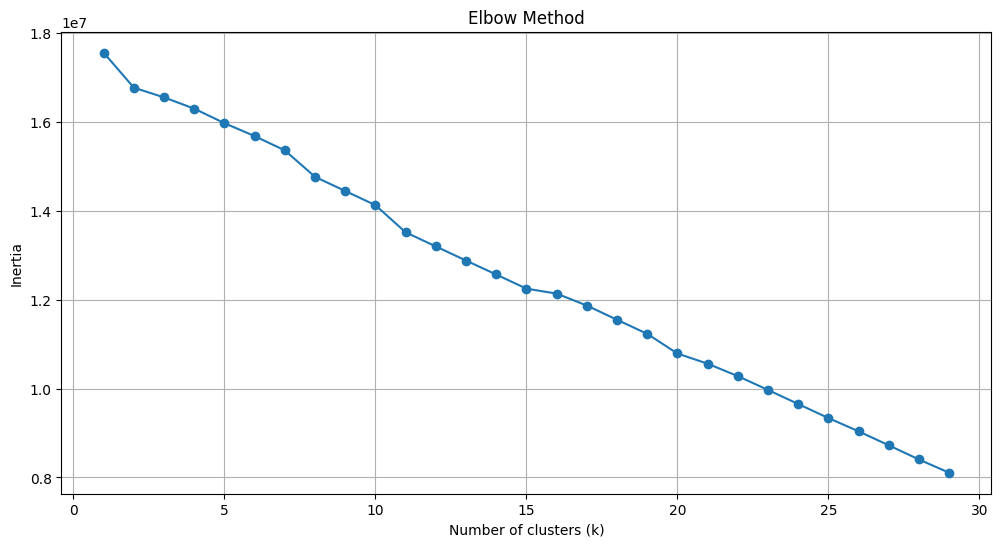

In [31]:
# Using elbow method to identify clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 30):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 30), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42,max_iter=1000)
kmeans.fit(X_scaled)

# Assign clusters to your data
homicide_data["Cluster"] = kmeans.labels_

In [122]:
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Cluster
484984,87,20,1996,8,1,1,0,8,0,0,2,8
608445,539,30,2013,9,1,1,25,8,0,0,5,10
417612,1695,22,1997,11,1,1,0,6,0,0,5,4
372692,425,9,1995,12,1,1,20,0,0,0,1,9
402028,946,4,2002,11,1,1,25,8,0,0,3,10


In [33]:
print(homicide_data["Cluster"].value_counts())

Cluster
0    247369
1     71858
Name: count, dtype: int64


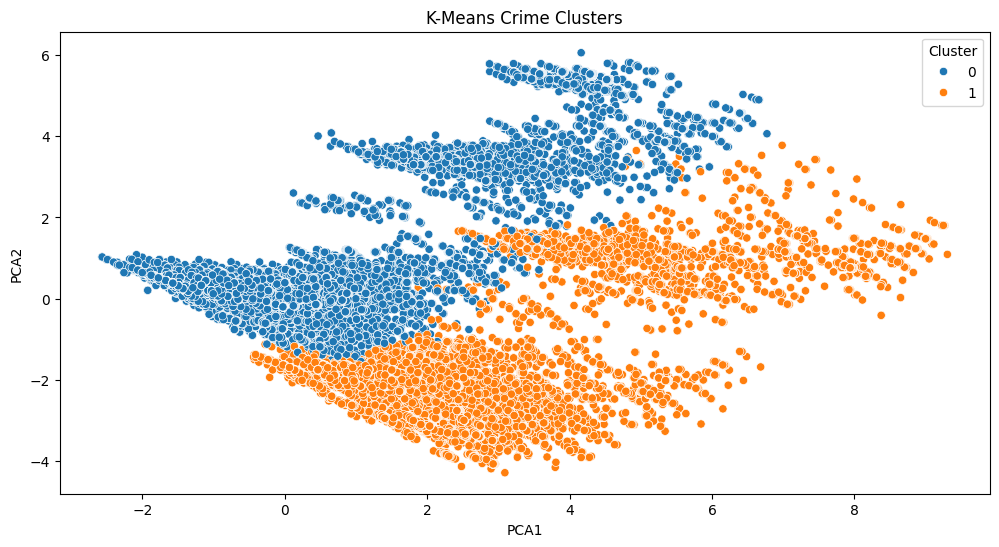

In [35]:
# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

<ipython-input-36-2828eef811a9>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')


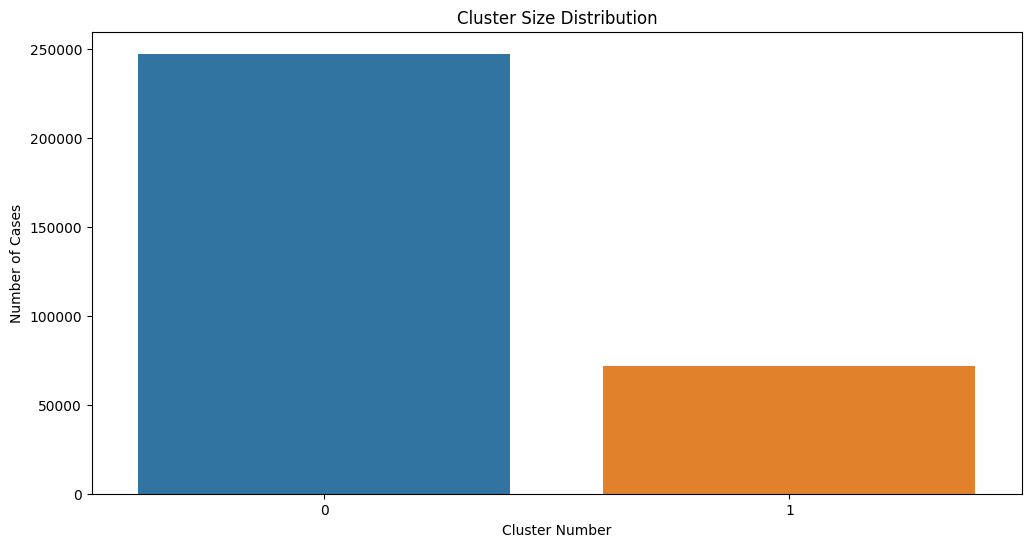

In [36]:
# Count the number of cases per cluster
cluster_counts = homicide_data['Cluster'].value_counts().sort_index()

# Bar chart of cluster sizes
plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Cases')
plt.title('Cluster Size Distribution')
plt.show()


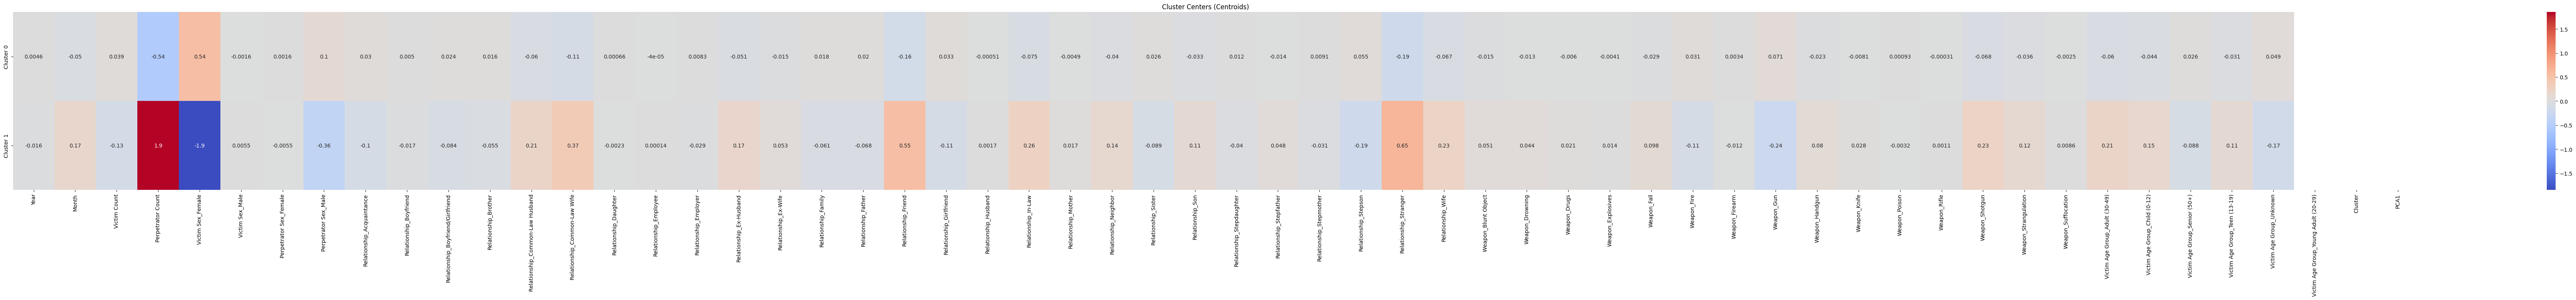

In [43]:
# You can also explore cluster centers
centroids = kmeans.cluster_centers_

# Plot centroids to understand cluster centers
plt.figure(figsize=(100, 6))
sns.heatmap(centroids, annot=True, cmap='coolwarm', xticklabels=homicide_data.columns[:-1], yticklabels=[f'Cluster {i}' for i in range(kmeans.n_clusters)])
plt.title("Cluster Centers (Centroids)")
plt.show()

In [38]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29),Cluster,PCA1,PCA2
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,1980,1,0,0,True,False,False,True,False,False,...,False,False,False,False,False,False,True,1,1.446218,-2.956926
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,False,False,True,0,-1.531028,0.375642
1980-01-01,1980,1,0,0,False,True,False,True,False,False,...,False,True,False,False,False,False,False,0,-0.384418,0.262454
1980-01-01,1980,1,0,0,False,True,True,False,False,True,...,False,False,False,False,False,False,True,0,3.712174,5.381860
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,True,False,False,False,False,False,0,-1.130743,0.321072


In [44]:
# Define which cluster represent serial killers based on analysis
serial_killer_clusters = {1}

# Create a new column in the dataset to mark serial vs. non-serial crimes
homicide_data["Serial_Label"] = homicide_data["Cluster"].apply(lambda x: "Serial" if x in serial_killer_clusters else "Not Serial")

In [45]:
homicide_data.head()

,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29),Cluster,PCA1,PCA2,Serial_Label
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,1980,1,0,0,True,False,False,True,False,False,...,False,False,False,False,False,True,1,1.446218,-2.956926,Serial
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,False,False,False,False,False,True,0,-1.531028,0.375642,Not Serial
1980-01-01,1980,1,0,0,False,True,False,True,False,False,...,True,False,False,False,False,False,0,-0.384418,0.262454,Not Serial
1980-01-01,1980,1,0,0,False,True,True,False,False,True,...,False,False,False,False,False,True,0,3.712174,5.381860,Not Serial
1980-01-01,1980,1,0,0,False,True,False,True,True,False,...,True,False,False,False,False,False,0,-1.130743,0.321072,Not Serial


In [46]:
homicide_data = homicide_data.drop(columns=["Cluster","PCA1","PCA2"])

In [50]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/DSGP/homicide_serial_labeled.csv"
homicide_data.to_csv(save_path, index=False)
print(f"Dataset saved to {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset saved to /content/drive/MyDrive/DSGP/homicide_serial_labeled.csv


In [47]:
# split features
X = homicide_data.drop(columns=["Serial_Label"])
y = homicide_data["Serial_Label"]

In [48]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
# Give a simple rf model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Give classification report
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))


Training Accuracy: 1.0
              precision    recall  f1-score   support

  Not Serial       1.00      1.00      1.00    173127
      Serial       1.00      1.00      1.00     50331

    accuracy                           1.00    223458
   macro avg       1.00      1.00      1.00    223458
weighted avg       1.00      1.00      1.00    223458



,Year,Month,Victim Count,Perpetrator Count,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,Relationship_Acquaintance,Relationship_Boyfriend,...,Weapon_Strangulation,Weapon_Suffocation,Victim Age Group_Adult (30-49),Victim Age Group_Child (0-12),Victim Age Group_Senior (50+),Victim Age Group_Teen (13-19),Victim Age Group_Unknown,Victim Age Group_Young Adult (20-29),PCA1,PCA2
Cluster,,,,,,,,,,,,,,,,,,,,,
0,98.624620,11.620133,0.214638,0.383934,0.000000,0.000000,0.070293,0.070293,0.219219,0.014251,...,0.004972,0.003384,0.226461,0.021917,0.118980,0.110090,0.011100,0.229206,1.799032,1.354366
1,97.970662,11.732814,0.533682,0.193973,0.004309,0.004309,0.071883,0.071883,0.247649,0.000501,...,0.037037,0.015627,0.228062,0.065304,0.164962,0.081373,0.026914,0.188732,2.350364,1.246023


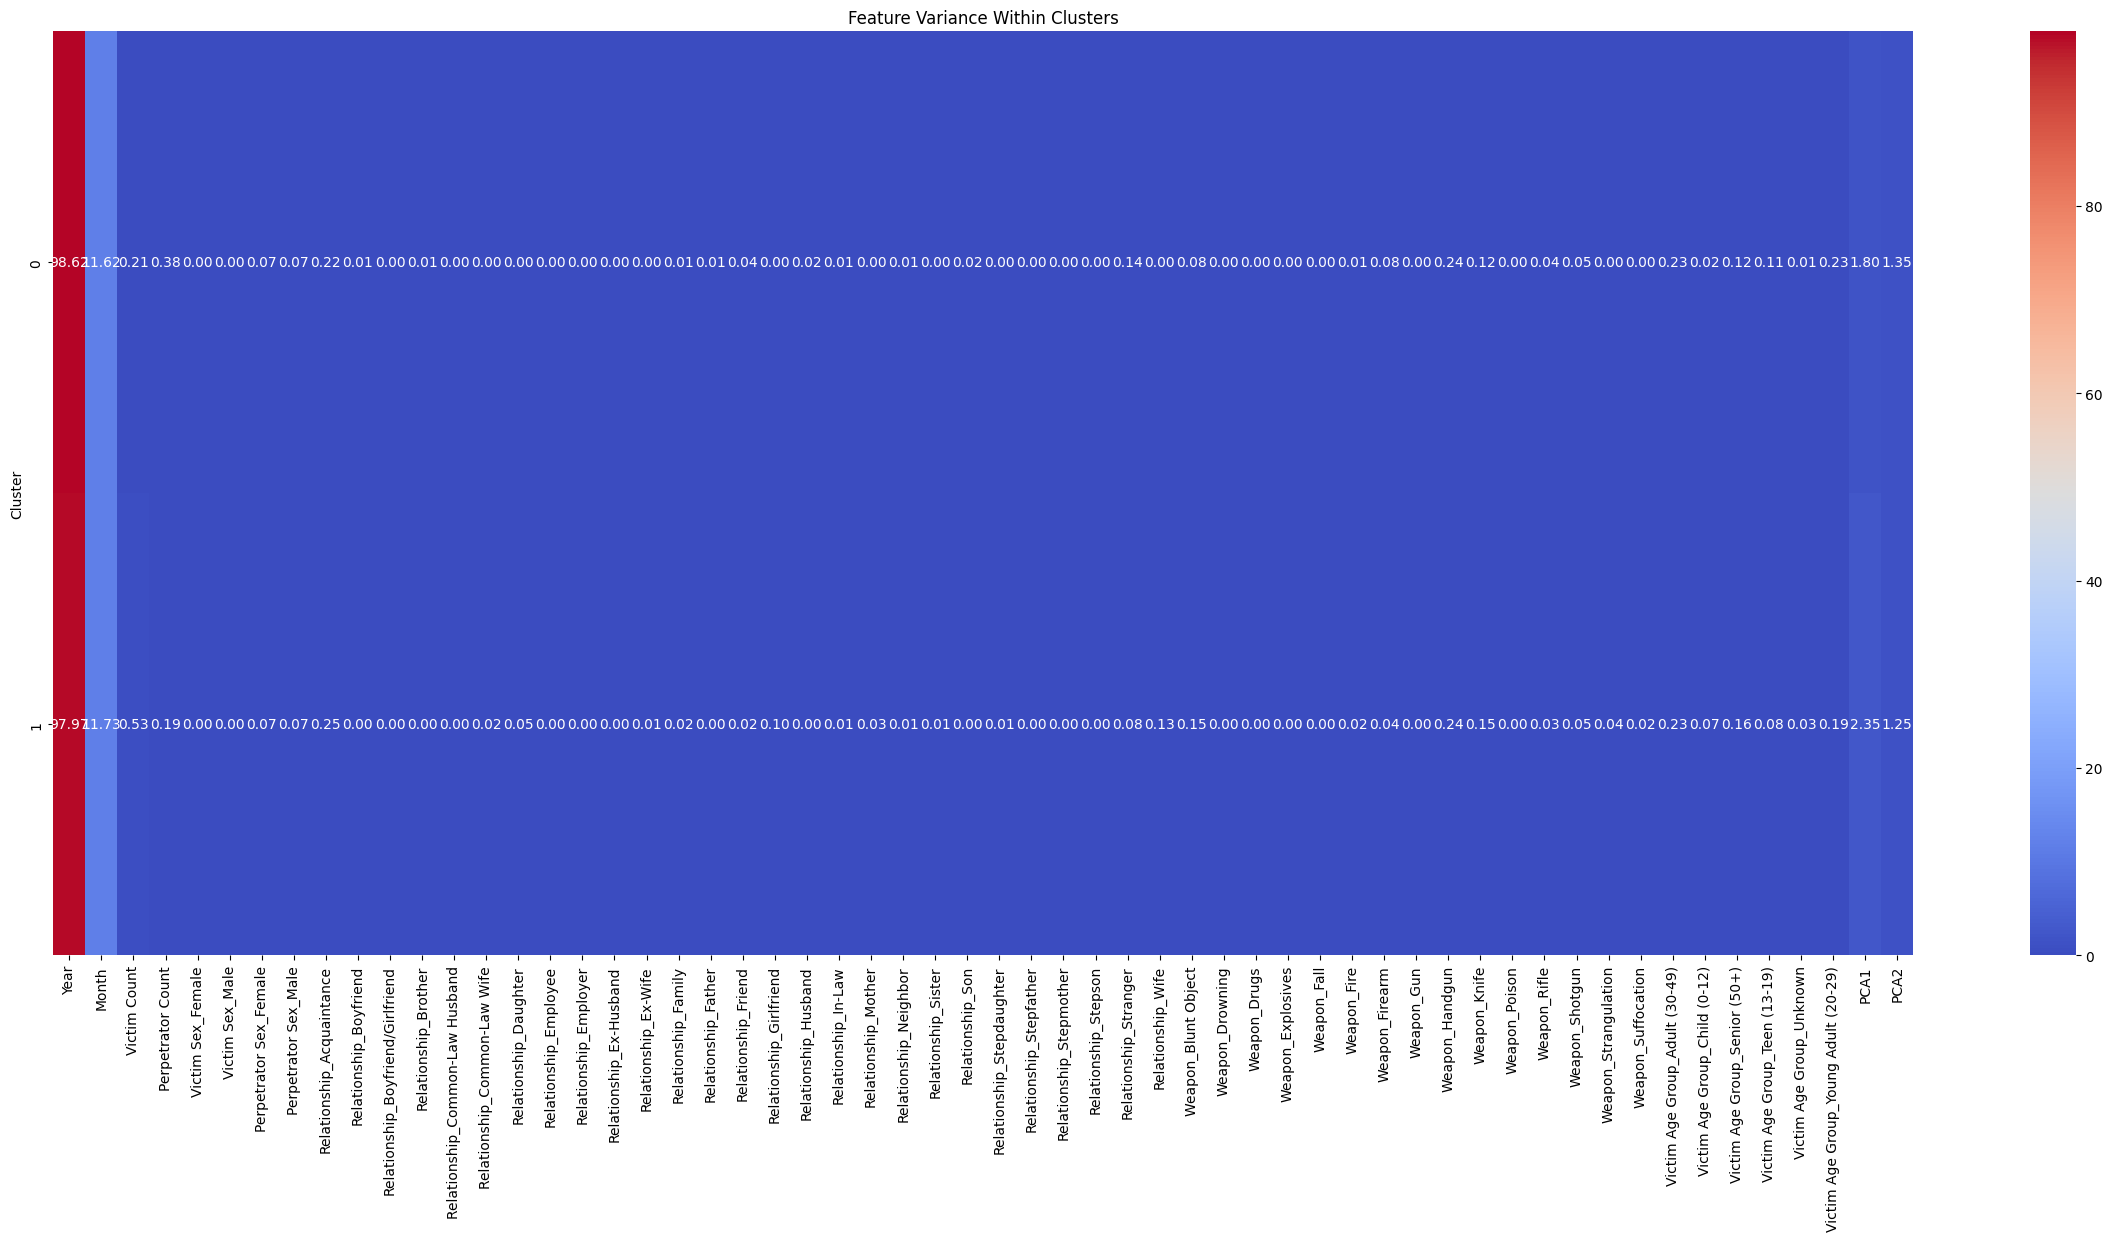

In [39]:
# Calculate feature variance within clusters
feature_variance = homicide_data.groupby('Cluster').var()
display(feature_variance)

# Visualize feature variance across clusters
plt.figure(figsize=(30, 12))
sns.heatmap(feature_variance, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Feature Variance Within Clusters")
plt.show()


In [40]:
# Step 2: Calculate the centroids of the clusters
centroids = kmeans.cluster_centers_

# Step 3: Compute the Euclidean distances between the centroids
distances = np.linalg.norm(centroids[:, np.newaxis] - centroids, axis=2)

# Step 4: Print the distances between each pair of centroids
print("Euclidean distances between each pair of centroids:")
for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        print(f"Distance between Cluster {i} and Cluster {j}: {distances[i, j]:.4f}")

Euclidean distances between each pair of centroids:
Distance between Cluster 0 and Cluster 1: 3.7574


In [41]:
low_variance_threshold = 0.1

for cluster in feature_variance.index:
    cluster_variance = feature_variance.loc[cluster]
    low_variance_features = cluster_variance[cluster_variance < low_variance_threshold]

    print(f"Cluster {cluster} - Low variance features:")
    print(low_variance_features)
    print("---")


Cluster 0 - Low variance features:
Victim Sex_Female                    0.000000
Victim Sex_Male                      0.000000
Perpetrator Sex_Female               0.070293
Perpetrator Sex_Male                 0.070293
Relationship_Boyfriend               0.014251
Relationship_Boyfriend/Girlfriend    0.002303
Relationship_Brother                 0.010685
Relationship_Common-Law Husband      0.004034
Relationship_Common-Law Wife         0.000089
Relationship_Daughter                0.000295
Relationship_Employee                0.000614
Relationship_Employer                0.000788
Relationship_Ex-Husband              0.001268
Relationship_Ex-Wife                 0.000166
Relationship_Family                  0.012899
Relationship_Father                  0.008326
Relationship_Friend                  0.036560
Relationship_Girlfriend              0.000558
Relationship_Husband                 0.017299
Relationship_In-Law                  0.005616
Relationship_Mother                  0.000529

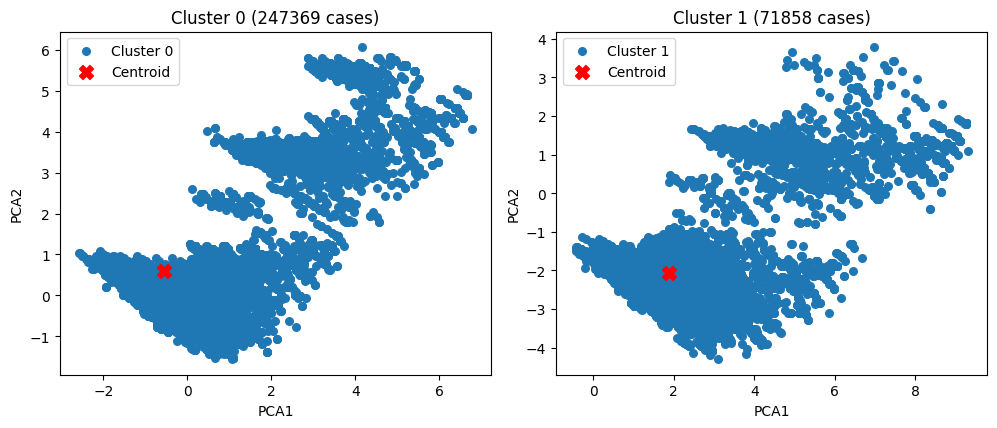

In [42]:
unique_clusters = homicide_data['Cluster'].unique()
num_clusters = len(unique_clusters)

# Create subplots (4x4 grid to fit 14 clusters, leaving 2 empty)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, cluster in enumerate(sorted(unique_clusters)):
    ax = axes[i]
    cluster_data = homicide_data[homicide_data['Cluster'] == cluster]

    # Scatter plot of the cluster points
    ax.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', s=30)

    # Calculate and plot the centroid (mean of PCA1 and PCA2)
    centroid_x = cluster_data['PCA1'].mean()
    centroid_y = cluster_data['PCA2'].mean()
    ax.scatter(centroid_x, centroid_y, color='red', marker='X', s=100, label='Centroid')

    count = len(cluster_data)
    ax.set_title(f'Cluster {cluster} ({count} cases)')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.legend()

# Hide unused subplots (since 16 subplots but only 14 clusters)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [74]:
centroids = kmeans.cluster_centers_

# Apply PCA to reduce centroids' coordinates to 2D
pca = PCA(n_components=2)
centroids_2d = pca.fit_transform(centroids)  # Transform centroids into 2D space

# Print the 2D coordinates of the centroids
for i, centroid in enumerate(centroids_2d):
    print(f"Centroid of Cluster {i}: {centroid}")

Centroid of Cluster 0: [ 7.10685077 -0.08394062]
Centroid of Cluster 1: [-0.82153563 -0.30227965]
Centroid of Cluster 2: [-0.64170292  3.63129558]
Centroid of Cluster 3: [-0.84969311 -0.06928447]
Centroid of Cluster 4: [-0.77269309 -0.30666944]
Centroid of Cluster 5: [-0.95280536 -1.63251933]
Centroid of Cluster 6: [-0.8619974  -0.02806607]
Centroid of Cluster 7: [-0.84160236 -0.42565472]
Centroid of Cluster 8: [-0.45145644 -0.58529611]
Centroid of Cluster 9: [-0.91336446 -0.19758517]


Advanced

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


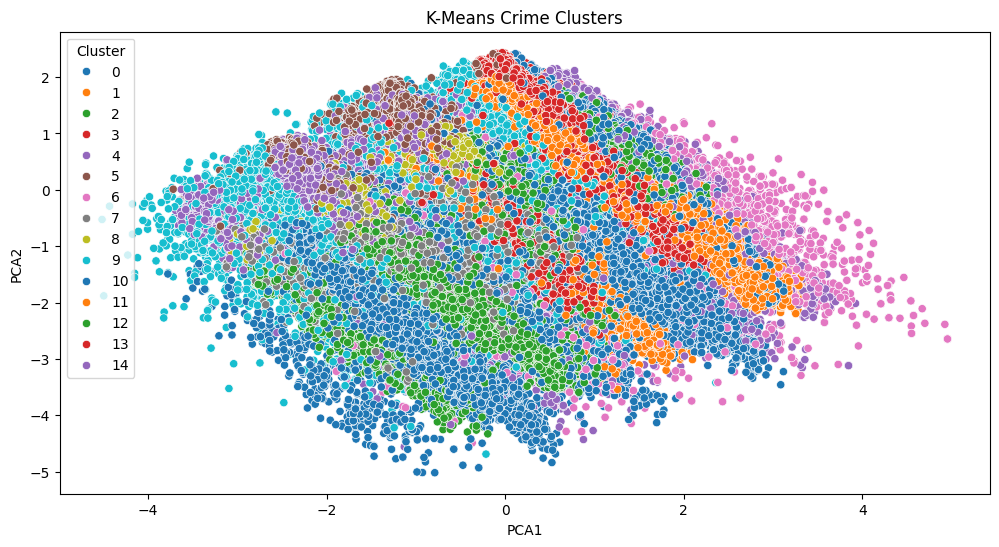

In [23]:
# K-Means Clustering
kmeans = KMeans(n_clusters=15, random_state=42)
homicide_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

In [24]:
homicide_data['Cluster'].value_counts()

,count
Cluster,
13,64649
1,61212
10,58651
4,55459
8,52187
3,49601
5,48000
2,46982
12,46345


In [25]:
top_clusters = homicide_data['Cluster'].value_counts().head(2).index.tolist()
homicide_data['Serial_Crime'] = homicide_data['Cluster'].apply(lambda x: 1 if x in top_clusters else 0)

In [26]:
# Value count for serial crime
homicide_data['Serial_Crime'].value_counts()

,count
Serial_Crime,
0,512593
1,125861


In [28]:
# Use features and target
y = homicide_data['Serial_Crime']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Build KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on training data
y_train_pred = knn.predict(X_train)

# Predict on test data
y_test_pred = knn.predict(X_test)

# Accuracy report
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))

# Detailed classification report
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358782
           1       1.00      1.00      1.00     88135

    accuracy                           1.00    446917
   macro avg       1.00      1.00      1.00    446917
weighted avg       1.00      1.00      1.00    446917


Testing Accuracy: 0.997253794306061
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    153811
           1       0.99      0.99      0.99     37726

    accuracy                           1.00    191537
   macro avg       1.00      0.99      1.00    191537
weighted avg       1.00      1.00      1.00    191537



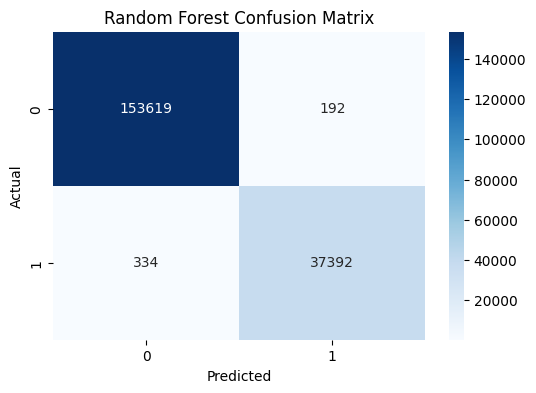

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Accuracy Reports
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=5)
homicide_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Crime Clusters')
plt.show()

NameError: name 'DBSCAN' is not defined

In [ ]:
# Check cluster composition
for cluster in homicide_data['KMeans_Cluster'].unique():
    print(f"\nCluster {cluster} sample crimes:")
    print(homicide_data[homicide_data['KMeans_Cluster'] == cluster][features].head())